In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pld

In [2]:
df = pd.read_csv("data/game_of_thrones.csv")
df.head(10)

,name,allegiance,season,episode,location,killer,killers_house,method,death_no
0,Waymar Royce,Night's Watch,1,1,Beyond the Wall,White Walker,NaN,Ice sword,1
1,Gared,Night's Watch,1,1,Beyond the Wall,White Walker,NaN,Ice sword,2
2,Will,Night's Watch,1,1,Winterfell,Ned Stark,House Stark,Sword,3
3,Stag,NaN,1,1,Winterfell,Direwolf,NaN,Teeth,4
4,Direwolf,NaN,1,1,Winterfell,Stag,NaN,Antler,5
5,Jon Arryn,House Arryn,1,1,King's Landing,Lysa Arryn,House Arryn,Poison,6
6,Dothraki man,Dothraki,1,1,Pentos,Dothraki man,Dothraki,Arakh,7
7,Catspaw assassin,NaN,1,2,Winterfell,Summer,House Stark,Teeth,8
8,Mycah,Smallfolk,1,2,Kingsroad,"Sandor ""the Hound"" Clegane",House Lannister,Sword,9
9,Lady,House Stark,1,2,Kingsroad,Ned Stark,House Stark,Knife,10


Contiene todo los datos de las muertes de Juego de Tronos
name: Nombre de la victima, season: Temporada, method: Cómo ha muerto
, death_no: El número de muerte en la serie, location: Lugar del asesinato, killer: Asesino

Información de nuestro DF.  string: "Desconocido", number: 0

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           2224 non-null   str  
 1   allegiance     1792 non-null   str  
 2   season         2224 non-null   int64
 3   episode        2224 non-null   int64
 4   location       2224 non-null   str  
 5   killer         2214 non-null   str  
 6   killers_house  2194 non-null   str  
 7   method         2224 non-null   str  
 8   death_no       2224 non-null   int64
dtypes: int64(3), str(6)
memory usage: 156.5 KB


In [4]:
df = df.fillna({"allegiance": "Desconocido"
                , "killers_house": "Desconocido"
                , "killer": "Desconocido"}) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           2224 non-null   str  
 1   allegiance     2224 non-null   str  
 2   season         2224 non-null   int64
 3   episode        2224 non-null   int64
 4   location       2224 non-null   str  
 5   killer         2224 non-null   str  
 6   killers_house  2224 non-null   str  
 7   method         2224 non-null   str  
 8   death_no       2224 non-null   int64
dtypes: int64(3), str(6)
memory usage: 156.5 KB


Podemos hacer de todo, por ejemplo, quedarnos con las cosas de la Temporada 1

In [11]:
df_temp1 = df[df["season"] == 1]
muertes_temp1 = df_temp1.shape[0]
muertes_totales = df.shape[0]
impacto_temp1 = round(muertes_temp1/muertes_totales* 100,2)
impacto_temp1
df_temp2 = df[df["season"] == 2]
muertes_temp2 = df_temp2.shape[0]
impacto_temp2 = round(muertes_temp2/muertes_totales* 100,2)
impacto_temp2
df_temp3 = df[df["season"] == 3]
muertes_temp3 = df_temp3.shape[0]
impacto_temp3 = round(muertes_temp3/muertes_totales* 100,2)
impacto_temp3

3.87

In [12]:
data = {
    "Temporadas": ['Temporada 1', 'Temporada 2', 'Temporada 3'],
    "Impacto": [impacto_temp1, impacto_temp2, impacto_temp3]
}
df_impacto = pd.DataFrame.from_dict(data)
df_impacto

,Temporadas,Impacto
0,Temporada 1,2.61
1,Temporada 2,5.85
2,Temporada 3,3.87


<Axes: xlabel='Temporadas'>

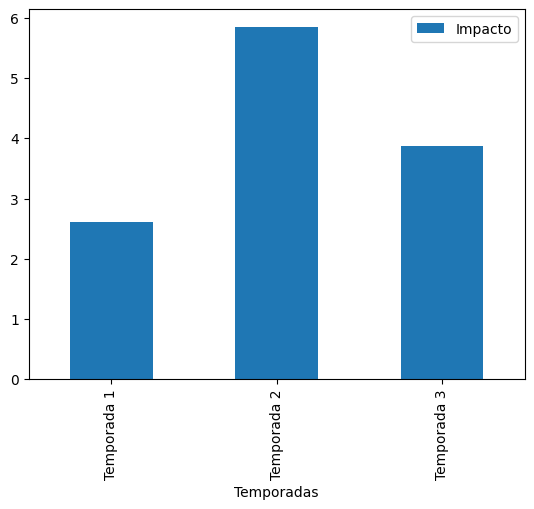

In [13]:
df_impacto.plot(kind='bar', x='Temporadas', y='Impacto')

In [14]:
df_season = df.groupby('season')['name']
df_season.describe()

,count,unique,top,freq
season,,,,
1,58,37,Stark soldier,12
2,130,40,Baratheon of Dragonstone soldier,55
3,86,30,Stark soldier,27
4,170,43,Wildling,61
5,158,36,Sons of the Harpy agent,67
6,396,53,King's Landing Noble,138
7,334,20,Lannister soldier,204
8,892,29,Golden Company soldier,374


Me gustaría saber el nombre del asesino y su número de muertes

In [16]:
df_killer = df.groupby('killer')['death_no'].agg(['count'])
df_killer

,count
killer,
Wildling giant,2
Wun Wun,3
Yara Greyjoy,11
Ygritte,14
Yoren,5


Quiero saber cuantas muertes ha realizado Daenerys Targaryen

In [27]:
kaleshi = df [ df['killer'] == 'Daenerys Targaryen']
kaleshi.groupby('method').sum()

,name,allegiance,season,episode,location,killer,killers_house,death_no
method,,,,,,,,
Claws (Dragon),Sons of the Harpy agentSons of the Harpy agent,Sons of the HarpySons of the Harpy,10,18,MeereenMeereen,Daenerys TargaryenDaenerys Targaryen,House TargaryenHouse Targaryen,1145
Dragonfire (Dragon),Pyat PreeKraznys mo NaklozGoatZallaSons of the...,Warlocks of QarthGood MastersDesconocidoSmallf...,7597,4849,QarthAstaporMeereenMeereenMeereenMeereenMeeree...,Daenerys TargaryenDaenerys TargaryenDaenerys T...,House TargaryenHouse TargaryenHouse TargaryenH...,1611634
Fire,Mirri Maz DuurKhal MoroDothraki KhalDothraki K...,DesconocidoDothrakiDothrakiDothrakiDothrakiDot...,91,70,Red WasteVaes DothrakVaes DothrakVaes DothrakV...,Daenerys TargaryenDaenerys TargaryenDaenerys T...,House TargaryenHouse TargaryenHouse TargaryenH...,9628
Pillow,Khal Drogo,Dothraki,1,10,Red Waste,Daenerys Targaryen,House Targaryen,57
Rubble,Jaime LannisterCersei Lannister,House LannisterHouse Lannister,16,10,King's LandingKing's Landing,Daenerys TargaryenDaenerys Targaryen,House TargaryenHouse Targaryen,4445
Sealed into vault,Xaro Xhoan DaxosDoreah,The ThirteenHouse Targaryen,4,20,QarthQarth,Daenerys TargaryenDaenerys Targaryen,House TargaryenHouse Targaryen,375
Teeth (Dragon),Sons of the Harpy agentSons of the Harpy agent,Sons of the HarpySons of the Harpy,10,18,MeereenMeereen,Daenerys TargaryenDaenerys Targaryen,House TargaryenHouse Targaryen,1163
